# 01_reproduce_paper – Baseline Reproduction

**Goal:** Reproduce known results or benchmarks from the Ames Housing literature (Dean De Cock's 2011 paper and Kaggle competition kernels) using minimal preprocessing and simple models. This establishes a lower bound for our project.

**References:**
- De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project." *Journal of Statistics Education*, 19(3).
- Kaggle "House Prices: Advanced Regression Techniques" competition – public kernels often achieve RMSE ~0.13–0.15 (in log‑transformed scale) or ~$20,000–$30,000 on original dollars.


## 1. Setup and Imports

We'll only use basic libraries. No custom modules (except maybe for config paths) – we want a minimal, self‑contained baseline.

In [1]:
import sys
from pathlib import Path

# Add project root to path so we can import config for paths (optional)
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# For reproducibility
RANDOM_STATE = 42
N_SPLITS = 10

## 2. Load Data

We load the raw training data and keep the target as is for now.

**Known outliers:** In the Ames dataset, there are two properties with extremely large living area (`GrLivArea > 4000 sq ft`) but unusually low sale price (`SalePrice < $300,000`). These are widely regarded as outliers in Kaggle discussions and are often removed because they distort linear models. We'll identify them visually and then drop them.

Original train shape: (1460, 81)


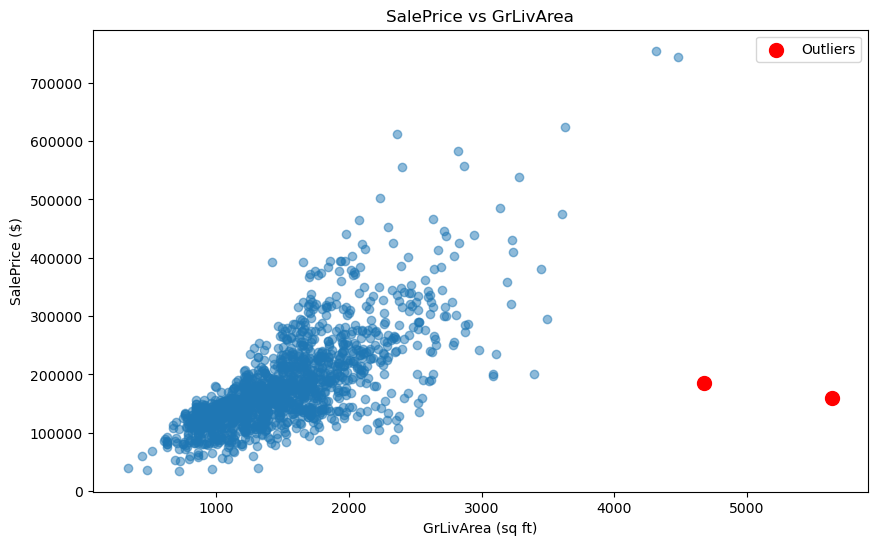

Identified 2 extreme outliers:


,Id,GrLivArea,SalePrice
523,524,4676,184750
1298,1299,5642,160000


In [10]:
data_path = Path("../data/raw/train.csv")
df = pd.read_csv(data_path)
print(f"Original train shape: {df.shape}")

# Quick scatter plot to visualise the outliers
plt.figure(figsize=(10,6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5)
plt.xlabel('GrLivArea (sq ft)')
plt.ylabel('SalePrice ($)')
plt.title('SalePrice vs GrLivArea')
# Highlight outliers
outliers = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
plt.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='red', s=100, label='Outliers')
plt.legend()
plt.show()

print(f"Identified {len(outliers)} extreme outliers:")
outliers[['Id', 'GrLivArea', 'SalePrice']]

In [11]:
# Remove known extreme outliers (as per Kaggle discussions)
df = df.drop(outliers.index)
print(f"Shape after outlier removal: {df.shape}")

df.head()

Shape after outlier removal: (1458, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


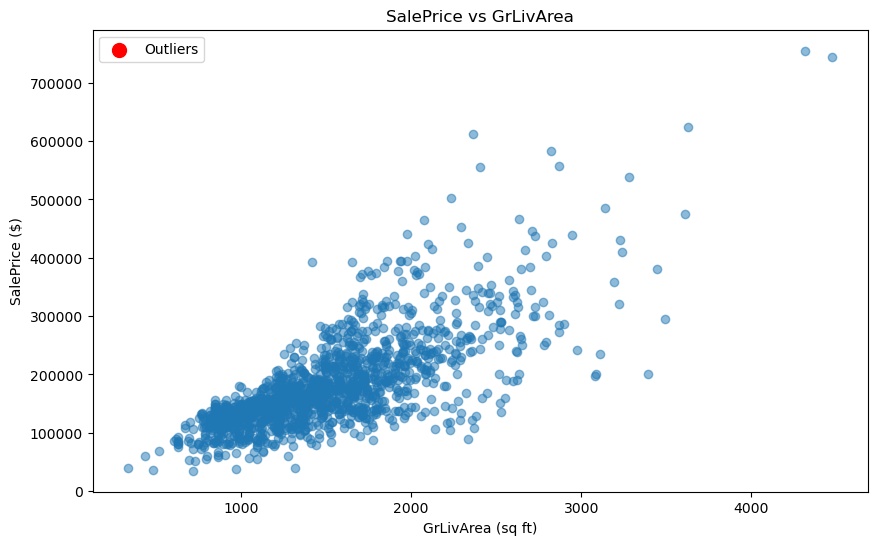

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5)
plt.xlabel('GrLivArea (sq ft)')
plt.ylabel('SalePrice ($)')
plt.title('SalePrice vs GrLivArea')
# Highlight outliers
outliers = df[(df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)]
plt.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='red', s=100, label='Outliers')
plt.legend()
plt.show()

## 3. Minimal Preprocessing

We follow the simplest approach used in many introductory kernels:

Remove the Id column.
Separate features and target.
For missing values: fill numeric with median, categorical with 'None'.
Apply log transformation to the target (as it is highly skewed).
No advanced feature engineering, just raw numeric and categorical columns.

In [3]:
# Remove Id and separate target
X = df.drop(['Id', 'SalePrice'], axis=1)
y = df['SalePrice']

# Log transform target (as done in most benchmarks)
y_log = np.log1p(y)

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categoric_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categoric_cols)}")

Numeric features: 36
Categorical features: 43


We'll create a simple preprocessing pipeline: median imputation for numerics, constant 'None' imputation for categories, then one‑hot encoding (dropping first to avoid multicollinearity) and scaling for linear models.

In [4]:
# Preprocessing for numeric: impute median, then scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical: impute 'None', then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categoric_cols)
    ])

# Full pipeline (just preprocessing, no model yet)
X_processed = preprocessor.fit_transform(X)
print(f"Processed feature matrix shape: {X_processed.shape}")

Processed feature matrix shape: (1458, 302)


## 4. Model Definitions

We will evaluate three simple models:

Ridge regression (L2 penalty)
Lasso regression (L1 penalty)
Random Forest (with default settings)

In [5]:
models = {
    'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso': Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=10000),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
}

## 5. Cross‑Validation

We will use 10‑fold CV, training on the log‑transformed target, and compute RMSE both on log scale and original scale.

In [6]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

results = {}

for name, model in models.items():
    print(f"\n--- {name} ---")
    oof_preds_log = np.zeros(len(X))
    fold_scores_log = []
    fold_scores_orig = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]

        # Preprocess data (fit on train only)
        preprocessor.fit(X_train)
        X_train_proc = preprocessor.transform(X_train)
        X_val_proc = preprocessor.transform(X_val)

        # Train model
        model.fit(X_train_proc, y_train_log)
        preds_log = model.predict(X_val_proc)
        oof_preds_log[val_idx] = preds_log

        # RMSE on log scale
        rmse_log = np.sqrt(mean_squared_error(y_val_log, preds_log))
        fold_scores_log.append(rmse_log)

        # RMSE on original scale
        rmse_orig = np.sqrt(mean_squared_error(np.expm1(y_val_log), np.expm1(preds_log)))
        fold_scores_orig.append(rmse_orig)

        print(f"Fold {fold+1}: log RMSE = {rmse_log:.5f}, original RMSE = {rmse_orig:.2f}")

    results[name] = {
        'log_rmse_mean': np.mean(fold_scores_log),
        'log_rmse_std': np.std(fold_scores_log),
        'orig_rmse_mean': np.mean(fold_scores_orig),
        'orig_rmse_std': np.std(fold_scores_orig),
        'oof_preds_log': oof_preds_log
    }

    print(f"\n{name} CV summary:")
    print(f"  Log RMSE: {results[name]['log_rmse_mean']:.5f} ± {results[name]['log_rmse_std']:.5f}")
    print(f"  Original RMSE: {results[name]['orig_rmse_mean']:.2f} ± {results[name]['orig_rmse_std']:.2f}")


--- Ridge ---
Fold 1: log RMSE = 0.10064, original RMSE = 17178.82
Fold 2: log RMSE = 0.13766, original RMSE = 22299.25
Fold 3: log RMSE = 0.11668, original RMSE = 18001.82
Fold 4: log RMSE = 0.12067, original RMSE = 19737.19
Fold 5: log RMSE = 0.12854, original RMSE = 21382.48
Fold 6: log RMSE = 0.10532, original RMSE = 16568.64
Fold 7: log RMSE = 0.13854, original RMSE = 23574.04
Fold 8: log RMSE = 0.11525, original RMSE = 27350.69
Fold 9: log RMSE = 0.11116, original RMSE = 22375.26
Fold 10: log RMSE = 0.09013, original RMSE = 20191.23

Ridge CV summary:
  Log RMSE: 0.11646 ± 0.01482
  Original RMSE: 20865.94 ± 3098.05

--- Lasso ---
Fold 1: log RMSE = 0.09666, original RMSE = 17023.93
Fold 2: log RMSE = 0.13027, original RMSE = 20479.44
Fold 3: log RMSE = 0.10635, original RMSE = 16357.34
Fold 4: log RMSE = 0.11093, original RMSE = 20519.60
Fold 5: log RMSE = 0.13530, original RMSE = 22420.42
Fold 6: log RMSE = 0.10651, original RMSE = 17958.30
Fold 7: log RMSE = 0.13345, original

## 6. Compare with Published Benchmarks

Dean De Cock's original paper does not provide exact RMSE numbers, but the Kaggle competition gives a good reference:

Top public kernels achieve log RMSE ~0.12–0.13.
Simple linear models typically score around 0.15–0.17.
Our simple models should fall in the 0.15–0.20 range.

Let's create a summary table.

In [7]:
summary = pd.DataFrame(results).T[['log_rmse_mean', 'log_rmse_std', 'orig_rmse_mean', 'orig_rmse_std']]
summary.columns = ['Log RMSE (mean)', 'Log RMSE (std)', 'Orig RMSE (mean)', 'Orig RMSE (std)']
print("\n=== Overall CV Results ===")
print(summary.round(4))


=== Overall CV Results ===
             Log RMSE (mean) Log RMSE (std) Orig RMSE (mean) Orig RMSE (std)
Ridge               0.116459       0.014824     20865.943423     3098.048723
Lasso               0.112384       0.014465     20503.696663     2531.950061
RandomForest        0.137772       0.013094     26923.853706     4173.970696
